In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **cleaning**

In [ ]:
import pandas as pd
import re

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLP/shortjokes.csv")
print("Original:", len(df))

# remove nulls
df = df.dropna(subset=["Joke"])
df["Joke"] = df["Joke"].astype(str)
print("After dropna:", len(df))

# remove duplicates
df = df.drop_duplicates(subset=["Joke"])
print("After duplicates:", len(df))

# normalize whitespace
df["Joke"] = df["Joke"].apply(lambda x: re.sub(r"\s+", " ", x).strip())

# Remove empty strings
df = df[df["Joke"].str.strip() != ""]
print("After empty-string removal:", len(df))

# remove URLs
df = df[~df["Joke"].str.contains(r"http|www\.", case=False, regex=True)]
print("After URL removal:", len(df))

# remove encoding-corrupted text
df = df[~df["Joke"].str.contains(r"â|€|™|�", regex=True)]
print("After encoding cleanup:", len(df))

# word count filter
df["word_count"] = df["Joke"].apply(lambda x: len(x.split()))
df = df[(df["word_count"] >= 6) & (df["word_count"] <= 40)]
print("After word count filter:", len(df))

# remove rows that are only symbols
df = df[~df["Joke"].str.contains(r"^[^A-Za-z0-9]+$", regex=True)]
print("After symbol-only removal:", len(df))

# remove excessive repeated characters
df = df[~df["Joke"].str.contains(r"(.)\1{6,}", regex=True)]
print("After repeated-char removal:", len(df))

# remove rows with too many symbols
def too_many_symbols(text):
    symbols = sum(1 for c in text if not c.isalnum() and not c.isspace())
    return symbols / max(len(text), 1) > 0.3

df = df[~df["Joke"].apply(too_many_symbols)]
print("After symbol ratio filter:", len(df))

df = df.drop(columns=["word_count"])

df.to_csv("/content/drive/MyDrive/Colab Notebooks/NLP/shortjokes_cleaned.csv", index=False)

print("Final:", len(df))
print(df.head())


Original: 231657
After dropna: 231657
After duplicates: 231657
After empty-string removal: 231657
After URL removal: 230956
After encoding cleanup: 230956
After word count filter: 228390
After symbol-only removal: 228389


/tmp/ipykernel_813/1204747476.py:41: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df[~df["Joke"].str.contains(r"(.)\1{6,}", regex=True)]


After repeated-char removal: 227228
After symbol ratio filter: 227193
Final: 227193
   ID                                               Joke
0   1  [me narrating a documentary about narrators] "...
1   2  Telling my daughter garlic is good for you. Go...
2   3  I've been going through a really rough period ...
3   4  If I could have dinner with anyone, dead or al...
4   5     Two guys walk into a bar. The third guy ducks.


# **Data Reduction**

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLP/shortjokes_cleaned.csv")
print("Cleaned dataset size:", len(df))

main_n = min(2000, len(df))
reduced_df = df.sample(n=main_n, random_state=42)
print("Reduced dataset size:", len(reduced_df))

#discovery_n = min(300, len(reduced_df))
#discovery_df = reduced_df.sample(n=discovery_n, random_state=42)
#print("Discovery subset size:", len(discovery_df))

reduced_df.to_csv("/content/drive/MyDrive/Colab Notebooks/NLP/shortjokes_reduced_2000.csv", index=False)
#discovery_df.to_csv("/content/drive/MyDrive/Colab Notebooks/NLP/shortjokes_discovery_300.csv", index=False)

print(reduced_df.head())
#print(discovery_df.head())

Cleaned dataset size: 227193
Reduced dataset size: 2000
            ID                                               Joke
120338  122669  When you see someone driving with their shirt ...
23351    23752  Damn girl, are you a math book? Girl:No, why? ...
221634  225959  What do you get if you cross an eagle with a s...
144203  147009  Why do you always need to take 2 baptists on a...
59900    61004  Have you heard of the John Denver omelet? It's...


# **Toxicity Filtering**

In [ ]:
!pip install detoxify

In [ ]:
import pandas as pd
import numpy as np
from detoxify import Detoxify

# load reduced dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLP/shortjokes_reduced_2000.csv")
print("Before toxicity filtering:", len(df))

# load model once
model = Detoxify("original")

threshold = 0.6
batch_size = 128

safe_parts = []

jokes = df["Joke"].astype(str).tolist()

for start in range(0, len(jokes), batch_size):
    end = min(start + batch_size, len(jokes))
    batch_df = df.iloc[start:end].copy()
    batch_texts = batch_df["Joke"].astype(str).tolist()

    print(f"Processing rows {start} to {end} ...")

    scores = model.predict(batch_texts)

    toxicity = np.array(scores["toxicity"])
    severe_toxicity = np.array(scores["severe_toxicity"])
    obscene = np.array(scores["obscene"])
    insult = np.array(scores["insult"])
    identity_attack = np.array(scores["identity_attack"])
    threat = np.array(scores["threat"])

    safe_mask = (
        (toxicity < threshold) &
        (severe_toxicity < threshold) &
        (obscene < threshold) &
        (insult < threshold) &
        (identity_attack < threshold) &
        (threat < threshold)
    )

    batch_safe = batch_df[safe_mask]
    safe_parts.append(batch_safe)

# combine all safe batches
df_safe = pd.concat(safe_parts, ignore_index=True)

print("After toxicity filtering:", len(df_safe))

# save filtered dataset
df_safe.to_csv("/content/drive/MyDrive/Colab Notebooks/NLP/shortjokes_safe.csv", index=False)

print(df_safe.head())


Before toxicity filtering: 2000


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: None
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Processing rows 0 to 128 ...
Processing rows 128 to 256 ...
Processing rows 256 to 384 ...
Processing rows 384 to 512 ...
Processing rows 512 to 640 ...
Processing rows 640 to 768 ...
Processing rows 768 to 896 ...
Processing rows 896 to 1024 ...
Processing rows 1024 to 1152 ...
Processing rows 1152 to 1280 ...
Processing rows 1280 to 1408 ...
Processing rows 1408 to 1536 ...
Processing rows 1536 to 1664 ...
Processing rows 1664 to 1792 ...
Processing rows 1792 to 1920 ...
Processing rows 1920 to 2000 ...
After toxicity filtering: 1702
       ID                                               Joke
0  147009  Why do you always need to take 2 baptists on a...
1   61004  Have you heard of the John Denver omelet? It's...
2   93782  What is hitlers favorite yugio card? The blue ...
3   82225  inspired by frontpage's TIL about the guy fawk...
4  118456  Give me your best golf joke. I work with a guy...


# **Topic Discovery on the 300 Subset**

In [ ]:
import pandas as pd

# load safe dataset
df_safe = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLP/shortjokes_safe.csv")
print("Safe dataset size:", len(df_safe))

# sample 300 jokes for topic discovery
discovery_n = min(300, len(df_safe))
discovery_df = df_safe.sample(n=discovery_n, random_state=42).copy()

print("Discovery subset size:", len(discovery_df))

# save file
discovery_df.to_csv("/content/drive/MyDrive/Colab Notebooks/NLP/shortjokes_discovery_300.csv", index=False)

print(discovery_df.head())


Safe dataset size: 1702
Discovery subset size: 300
          ID                                               Joke
705   206178  You must work at subway...cause you`re givin` ...
809   194637  What's the difference between an oyster fisher...
1432    4953  s/o to the fact that ketchup is a smoothie b/c...
173   178833  How many stoners does it take to screw in a li...
513   159457  My heart goes out to all the single thermomete...


In [ ]:
import pandas as pd
import time
from openai import OpenAI

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLP/shortjokes_discovery_300.csv")

jokes = df["Joke"].astype(str).tolist()

batch_size = 20
batches = [jokes[i:i+batch_size] for i in range(0, len(jokes), batch_size)]

all_topics = []

for i, batch in enumerate(batches):

    print(f"\nProcessing batch {i+1}/{len(batches)}")

    jokes_text = "\n".join([f"{idx+1}. {j}" for idx, j in enumerate(batch)])

    prompt = f"""
You are analyzing jokes from a humor dataset.

For each joke, identify the main topic of the joke.

Instructions:
- Assign ONE short topic label for each joke.
- The label should describe the main theme of the joke.
- Do not explain.
- Do not group topics.

Return format:

1 - topic
2 - topic
3 - topic

Jokes:
{jokes_text}
"""

    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            temperature=0,
            messages=[
                {"role":"system","content":"You are a humor analysis assistant."},
                {"role":"user","content":prompt}
            ]
        )

        result = response.choices[0].message.content
        print(result)

        lines = result.split("\n")

        topics = []
        for line in lines:
            if "-" in line:
                topic = line.split("-",1)[1].strip()
                topics.append(topic)

        # Safety check
        if len(topics) != len(batch):
            print("WARNING: topic count mismatch, filling missing topics")
            while len(topics) < len(batch):
                topics.append("unknown")

        all_topics.extend(topics)

        time.sleep(1)

    except Exception as e:
        print("Error:", e)
        all_topics.extend(["unknown"] * len(batch))


print("Total topics collected:", len(all_topics))

# Attach topics to dataframe
df["Discovered_Topic"] = all_topics

# Save result
df.to_csv("/content/drive/MyDrive/Colab Notebooks/NLP/discovery_labeled_300.csv", index=False)

print(df.head())


Processing batch 1/15
1 - flirtation  
2 - dark humor  
3 - food  
4 - stoner humor  
5 - puns  
6 - wordplay  
7 - cultural humor  
8 - disappointment  
9 - existential  
10 - drug humor  
11 - family dynamics  
12 - dark humor  
13 - wordplay  
14 - superhero humor  
15 - travel  
16 - psychology  
17 - monk humor  
18 - dark humor  
19 - pricing  
20 - puns  

Processing batch 2/15
1 - politics  
2 - puns  
3 - relationships  
4 - humor  
5 - sarcasm  
6 - college  
7 - wordplay  
8 - dating  
9 - humor  
10 - food  
11 - family  
12 - dad jokes  
13 - wordplay  
14 - dark humor  
15 - family  
16 - OCD  
17 - puns  
18 - humor  
19 - wordplay  
20 - relationships  

Processing batch 3/15
1 - Tetris  
2 - Putin  
3 - Space  
4 - Valentine's Day  
5 - Elephants  
6 - Database  
7 - Coffee  
8 - Knock Knock  
9 - Fruit  
10 - Rwandan  
11 - Childhood  
12 - Janitor  
13 - Lightbulbs  
14 - Jazz  
15 - Mormons  
16 - Salad  
17 - Acronyms  
18 - Breakfast  
19 - Apology  
20 - World H

# **Topic Definition (Mapping / Normalization)**

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLP/discovery_labeled_300.csv")

print(df["Discovered_Topic"].value_counts().head(50))


Discovered_Topic
wordplay            17
puns                 9
politics             8
humor                7
Wordplay             7
dark humor           6
food                 6
relationships        5
dating               4
Dark Humor           4
crime                4
religion             3
marriage             3
absurdity            3
Politics             3
Relationships        3
animals              3
time travel          2
farming              2
family               2
Marriage             2
parenting            2
disease              2
stereotypes          2
theft                2
self-deprecation     2
psychology           2
sarcasm              2
travel               2
mental health        2
Health               2
technology           2
Animals              2
Humor                2
Database             1
Elephants            1
stoner humor         1
superhero humor      1
family dynamics      1
drug humor           1
existential          1
cultural humor       1
disappointment   

In [ ]:
import pandas as pd

# load discovery file
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLP/discovery_labeled_300.csv")

# normalize discovered topics
df["Discovered_Topic"] = (
    df["Discovered_Topic"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace("-", " ", regex=False)
)

# mapping dictionary: discovered label -> one clear final content topic
topic_map = {
    # humor style / structure -> General
    "dark humor": "General",
    "stoner humor": "Adult",
    "puns": "General",
    "pun": "General",
    "wordplay": "General",
    "cultural humor": "General",
    "superhero humor": "Entertainment",
    "humor": "General",
    "sarcasm": "General",
    "dad jokes": "Family",
    "body humor": "Health",
    "self deprecation": "General",
    "sexual humor": "Adult",
    "surreal": "General",
    "humor in instructions": "General",
    "lawyer humor": "Crime",
    "toilet humor": "Health",
    "anti jokes": "General",
    "absurdity": "General",
    "knock knock": "General",
    "laughter": "General",
    "blonde joke": "People",
    "nun joke": "Religion",
    "inappropriate humor": "Adult",

    # relationships
    "flirtation": "Relationships",
    "relationships": "Relationships",
    "dating": "Relationships",
    "valentine's day": "Relationships",
    "marriage": "Relationships",
    "breakup": "Relationships",
    "kissing": "Relationships",
    "infidelity": "Relationships",
    "romance": "Relationships",
    "consent": "Relationships",
    "compliment": "Relationships",
    "baby names": "Relationships",
    "age difference": "Relationships",
    "in laws": "Family",
    "role playing": "Relationships",

    # family
    "family dynamics": "Family",
    "family": "Family",
    "parenting": "Family",
    "childhood": "Family",
    "baby": "Family",

    # food / drink
    "food": "Food",
    "coffee": "Food",
    "fruit": "Food",
    "salad": "Food",
    "breakfast": "Food",
    "baking": "Food",
    "fast food": "Food",
    "wine": "Food",
    "barista": "Food",
    "soup": "Food",
    "cheese": "Food",
    "cereal prize": "Food",

    # politics / society
    "politics": "Politics",
    "putin": "Politics",
    "world hunger": "Politics",
    "inclusion": "Politics",
    "women": "People",
    "nationality": "People",
    "homelessness": "Society",
    "military": "Politics",
    "service industry": "Business",
    "ethics": "Society",
    "ethnicity": "People",
    "feminism": "Politics",
    "redneck": "People",
    "stereotypes": "People",
    "rwandan": "People",

    # religion
    "monk humor": "Religion",
    "religion": "Religion",
    "biblical": "Religion",
    "mormons": "Religion",
    "creation": "Religion",

    # health / medicine / psychology
    "psychology": "Health",
    "ocd": "Health",
    "health": "Health",
    "alzheimer's": "Health",
    "surgery": "Health",
    "mental health": "Health",
    "fitness": "Health",
    "loneliness": "Health",
    "illness": "Health",
    "disease": "Health",
    "hypochondria": "Health",
    "dyslexia": "Health",
    "nosebleed": "Health",
    "injury": "Health",
    "dental hygiene": "Health",
    "sex": "Adult",
    "alcoholism": "Health",
    "drug humor": "Adult",
    "weed": "Adult",
    "bdsm": "Adult",
    "bukkake": "Adult",

    # crime / law / violence / death
    "crime": "Crime",
    "restraining order": "Crime",
    "death": "Crime",
    "cannibalism": "Crime",
    "theft": "Crime",
    "piracy": "Crime",
    "lawyer": "Crime",
    "violence": "Crime",
    "music piracy": "Crime",
    "dracula": "Crime",

    # technology
    "tetris": "Technology",
    "database": "Technology",
    "robotics": "Technology",
    "technology": "Technology",
    "samsung": "Technology",
    "internet": "Technology",
    "engineering": "Technology",
    "gaming": "Technology",
    "email": "Technology",
    "keyboard smash": "Technology",

    # science / math / space
    "space": "Science",
    "math": "Science",
    "science": "Science",
    "quantum physics": "Science",
    "mathematics": "Science",

    # education / language
    "college": "Education",
    "acronyms": "Education",
    "quiz": "Education",
    "language": "Education",
    "grammar": "Education",
    "literature": "Education",
    "intelligence": "Education",

    # animals / nature
    "elephants": "Animals",
    "dinosaurs": "Animals",
    "pets": "Animals",
    "spider": "Animals",
    "camels": "Animals",
    "animals": "Animals",
    "monster": "Animals",
    "insect": "Animals",
    "turtle wax": "Animals",
    "chicken": "Animals",
    "scarecrow": "Animals",
    "farming": "Animals",
    "camouflage": "Animals",

    # entertainment / media / pop culture
    "jazz": "Entertainment",
    "netflix": "Entertainment",
    "music": "Entertainment",
    "movies": "Entertainment",
    "magic": "Entertainment",
    "star wars": "Entertainment",
    "film": "Entertainment",
    "casting": "Entertainment",
    "george lucas": "Entertainment",
    "celebrity": "Entertainment",
    "fantasy": "Entertainment",
    "sound effects": "Entertainment",

    # travel / places
    "travel": "Travel",
    "hotel": "Travel",
    "swimming": "Travel",
    "parade": "Travel",
    "jump rope": "Sports",

    # work / business / money
    "pricing": "Business",
    "janitor": "Business",
    "payment": "Business",
    "business": "Business",
    "butcher": "Business",

    # sports / games
    "competition": "Sports",
    "golf": "Sports",
    "baseball": "Sports",

    # life / existential / emotion
    "disappointment": "Life",
    "existential": "Life",
    "misfortune": "Life",
    "time travel": "Science",
    "nostalgia": "Life",
    "sleep": "Life",
    "awkwardness": "Life",
    "dream": "Life",
    "life": "Life",
    "aging": "Life",
    "age": "Life",

    # holidays / occasions
    "christmas": "Holidays",
    "christmas gift": "Holidays",

    # people / identity / specific human groups
    "spartan": "People",
    "neighbors": "People",

    # everyday objects / misc
    "lightbulbs": "General",
    "apology": "Life",
    "mannequins": "General",
    "tattoos": "People"
}

# apply mapping
df["Final_Topic"] = df["Discovered_Topic"].map(topic_map)

# fill anything still unmapped with "General"
df["Final_Topic"] = df["Final_Topic"].fillna("General")

# save mapped dataset
df.to_csv("/content/drive/MyDrive/Colab Notebooks/NLP/discovery_mapped_300.csv", index=False)

# show final topic counts
print("Final topic frequencies:\n")
print(df["Final_Topic"].value_counts())

print("\nSample rows:\n")
print(df[["Joke", "Discovered_Topic", "Final_Topic"]].head(20))

# show which original labels became General
general_labels = df[df["Final_Topic"] == "General"]["Discovered_Topic"].value_counts()
print("\nLabels mapped to General:\n")
print(general_labels)


Final topic frequencies:

Final_Topic
General          85
Relationships    28
Health           20
Food             17
Politics         16
Animals          16
Crime            15
Entertainment    13
Family           12
Technology       11
Life             10
People            9
Science           9
Religion          7
Education         7
Adult             6
Business          6
Travel            4
Sports            4
Society           3
Holidays          2
Name: count, dtype: int64

Sample rows:

                                                 Joke Discovered_Topic  \
0   You must work at subway...cause you`re givin` ...       flirtation   
1   What's the difference between an oyster fisher...       dark humor   
2   s/o to the fact that ketchup is a smoothie b/c...             food   
3   How many stoners does it take to screw in a li...     stoner humor   
4   My heart goes out to all the single thermomete...             puns   
5   Police nearly apprehended a drug dealer sellin...    

# **Topic Frequency & selection**

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLP/discovery_mapped_300.csv")
print(df["Final_Topic"].value_counts())

df_filtered = df[~df["Final_Topic"].isin(["General", "Adult"])]

topic_counts = df_filtered["Final_Topic"].value_counts()
print(topic_counts)

final_topics = topic_counts.head(5).index.tolist()

print("Final topics for generation:")
print(final_topics)

pd.DataFrame({"Topic": final_topics}).to_csv(
    "/content/drive/MyDrive/Colab Notebooks/NLP/final_topics.csv",
    index=False
)


Final_Topic
General          85
Relationships    28
Health           20
Food             17
Politics         16
Animals          16
Crime            15
Entertainment    13
Family           12
Technology       11
Life             10
People            9
Science           9
Religion          7
Education         7
Adult             6
Business          6
Travel            4
Sports            4
Society           3
Holidays          2
Name: count, dtype: int64
Final_Topic
Relationships    28
Health           20
Food             17
Animals          16
Politics         16
Crime            15
Entertainment    13
Family           12
Technology       11
Life             10
Science           9
People            9
Education         7
Religion          7
Business          6
Travel            4
Sports            4
Society           3
Holidays          2
Name: count, dtype: int64
Final topics for generation:
['Relationships', 'Health', 'Food', 'Animals', 'Politics']


# **Generation**

In [ ]:
# FEW-SHOT GENERATION

import os
import time
import random
import pandas as pd
from openai import OpenAI

# 1) SETTINGS

MAPPED_PATH = "/content/drive/MyDrive/Colab Notebooks/NLP/discovery_mapped_300.csv"
FINAL_TOPICS_PATH = "/content/drive/MyDrive/Colab Notebooks/NLP/final_topics.csv"
OUTPUT_PATH = "/content/drive/MyDrive/Colab Notebooks/NLP/generated_jokes_fewshot_balanced_final.csv"

MODEL_NAME = "gpt-4o-mini"
TEMPERATURE = 1.1
NUM_JOKES_PER_TOPIC = 10
FEW_SHOT_K = 2
MAX_RETRIES_PER_JOKE = 5
SLEEP_SECONDS = 1.0
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

# 2) LOAD DATA

mapped_df = pd.read_csv(MAPPED_PATH)
topics_df = pd.read_csv(FINAL_TOPICS_PATH)

print("Mapped dataset shape:", mapped_df.shape)
print("Topics dataset shape:", topics_df.shape)

# 3) CLEAN DATA

mapped_df = mapped_df.dropna(subset=["Joke", "Final_Topic"]).copy()
mapped_df["Joke"] = mapped_df["Joke"].astype(str).str.strip()
mapped_df["Final_Topic"] = mapped_df["Final_Topic"].astype(str).str.strip()

mapped_df = mapped_df[
    (mapped_df["Joke"] != "") &
    (mapped_df["Final_Topic"] != "")
].copy()

# exclude broad / less useful categories
mapped_filtered = mapped_df[
    ~mapped_df["Final_Topic"].isin(["General", "Adult"])
].copy()

print("\nFiltered topic counts:")
print(mapped_filtered["Final_Topic"].value_counts())

# use already saved final topics
final_topics = topics_df["Topic"].dropna().astype(str).str.strip().tolist()

# keep only topics that actually exist in mapped_filtered
final_topics = [topic for topic in final_topics if topic in mapped_filtered["Final_Topic"].unique()]

print("\nFinal topics for generation:")
print(final_topics)

if len(final_topics) == 0:
    raise ValueError("No valid topics found. Check final_topics.csv and discovery_mapped_300.csv")

# 4) OPENAI CLIENT

api_key = os.environ.get("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY not found in environment variables.")

client = OpenAI(api_key=api_key)

# 5) HELPER: GET FEW-SHOT EXAMPLES

def get_few_shot_examples(topic, df, k=2):
    """
    Randomly select k unique jokes from the SAME topic.
    """
    topic_examples = (
        df[df["Final_Topic"] == topic]["Joke"]
        .drop_duplicates()
        .tolist()
    )

    if len(topic_examples) < k:
        raise ValueError(
            f"Topic '{topic}' has only {len(topic_examples)} unique examples, fewer than FEW_SHOT_K={k}."
        )

    return random.sample(topic_examples, k)

# 6) PROMPT BUILDER

def build_few_shot_prompt(topic, topic_examples):
    examples_text = "\n".join(
        [f"Example {i+1}: {j}" for i, j in enumerate(topic_examples)]
    )

    prompt = f"""
You are generating jokes for an academic NLP experiment.

Task:
Generate ONE original, creative, one-line joke about: {topic}

Strict rules:
- Do NOT reuse common or well-known jokes
- Do NOT use classic joke templates (like "Why did...", "I told my doctor...")
- Avoid repeating structures from the examples
- Be creative and novel
- Keep it short and natural
- One line only
- No explanations

Examples (for style only, NOT content):
{examples_text}

Now generate ONE NEW and DIFFERENT joke about {topic}.
"""
    return prompt.strip()

# 7) OUTPUT CLEANING

def clean_generated_joke(text):
    text = str(text).strip()

    # remove wrapping quotes
    if len(text) >= 2 and (
        (text.startswith('"') and text.endswith('"')) or
        (text.startswith("'") and text.endswith("'"))
    ):
        text = text[1:-1].strip()

    # remove common assistant prefixes
    prefixes = [
        "Joke:",
        "joke:",
        "Here's a joke:",
        "Here is a joke:",
        "Sure,",
        "Sure!"
    ]
    for prefix in prefixes:
        if text.startswith(prefix):
            text = text[len(prefix):].strip()

    # one-line normalization
    text = " ".join(text.split())

    return text

# 8) OUTPUT VALIDATION

def is_valid_joke(text):
    if not text:
        return False

    lower = text.lower()
    word_count = len(text.split())

    # very short / very long
    if word_count < 4 or word_count > 35:
        return False

    # obvious meta answers
    blocked_starts = [
        "sure",
        "here",
        "of course",
        "certainly",
        "this joke",
        "i'm sorry"
    ]
    if any(lower.startswith(x) for x in blocked_starts):
        return False


    return True

# 9) GENERATE ONE JOKE

def generate_one_joke(topic, topic_examples):
    prompt = build_few_shot_prompt(topic, topic_examples)

    response = client.chat.completions.create(
        model=MODEL_NAME,
        temperature=TEMPERATURE,
        messages=[
            {
                "role": "system",
                "content": "You are a careful humor generation assistant."
            },
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    joke = response.choices[0].message.content.strip()
    joke = clean_generated_joke(joke)
    return joke, prompt

# 10) MAIN BALANCED GENERATION LOOP

results = []

for topic in final_topics:
    print("\n" + "=" * 60)
    print(f"Generating jokes for topic: {topic}")
    print("=" * 60)

    accepted_jokes_for_topic = set()
    successful_count = 0
    attempt_counter = 0

    while successful_count < NUM_JOKES_PER_TOPIC:
        attempt_counter += 1

        if attempt_counter > NUM_JOKES_PER_TOPIC * MAX_RETRIES_PER_JOKE * 3:
            print(f"Stopped early for topic '{topic}' to avoid infinite loop.")
            break

        try:
            # resample examples each time for a bit more diversity
            topic_examples = get_few_shot_examples(topic, mapped_filtered, k=FEW_SHOT_K)

            joke, prompt_used = generate_one_joke(topic, topic_examples)

            # validation
            if not is_valid_joke(joke):
                print(f"[Invalid skipped] {joke}")
                time.sleep(SLEEP_SECONDS)
                continue

            # deduplicate within same topic
            if joke in accepted_jokes_for_topic:
                print(f"[Duplicate skipped] {joke}")
                time.sleep(SLEEP_SECONDS)
                continue

            accepted_jokes_for_topic.add(joke)
            successful_count += 1

            results.append({
                "Topic": topic,
                "Sample_ID": f"{topic}_{successful_count}",
                "Prompt_Type": "few-shot",
                "Num_Examples": len(topic_examples),
                "Example_1": topic_examples[0] if len(topic_examples) > 0 else "",
                "Example_2": topic_examples[1] if len(topic_examples) > 1 else "",
                "Model": MODEL_NAME,
                "Temperature": TEMPERATURE,
                "Prompt": prompt_used,
                "Generated_Joke": joke
            })

            print(f"[{successful_count}/{NUM_JOKES_PER_TOPIC}] {joke}")
            time.sleep(SLEEP_SECONDS)

        except Exception as e:
            print(f"Error for topic '{topic}' on attempt {attempt_counter}: {e}")
            time.sleep(SLEEP_SECONDS)

# 11) SAVE RESULTS

generated_df = pd.DataFrame(results)

print("\nGenerated shape before final checks:", generated_df.shape)

# final safety dedup
if not generated_df.empty:
    generated_df = generated_df.drop_duplicates(subset=["Topic", "Generated_Joke"]).copy()

generated_df.to_csv(OUTPUT_PATH, index=False)

print("\nSaved generated jokes to:")
print(OUTPUT_PATH)

print("\nFinal shape:")
print(generated_df.shape)

print("\nCounts by topic:")
if not generated_df.empty:
    print(generated_df["Topic"].value_counts())

print("\nPreview:")
print(generated_df.head())

Mapped dataset shape: (300, 4)
Topics dataset shape: (5, 1)

Filtered topic counts:
Final_Topic
Relationships    28
Health           21
Food             17
Animals          17
Politics         15
Crime            15
Entertainment    13
People           11
Technology       11
Family           11
Life             10
Science           9
Religion          8
Education         6
Business          5
Travel            4
Sports            4
Society           3
Holidays          2
Name: count, dtype: int64

Final topics for generation:
['Relationships', 'Health', 'Food', 'Animals', 'Politics']

Generating jokes for topic: Relationships
[1/10] Being in a relationship is a lot like doing a jigsaw puzzle—just when you think you’ve found the right piece, you realize it fits better with someone else.
[2/10] Our relationship is like a software update; I push for it, but you insist we're doing just fine as we are.
[3/10] My partner said we need to communicate better, so now I send my love notes via Sna

# **check if the learning Examples are humorous or not**

In [ ]:
!pip install transformers torch -q

In [ ]:
from transformers import pipeline
import pandas as pd
import numpy as np

# =========================
# 1) Load generation file
# =========================

path = "/content/drive/MyDrive/Colab Notebooks/NLP/generated_jokes_fewshot_balanced_final.csv"
df = pd.read_csv(path)

print("Original file shape:", df.shape)
print(df.columns)

# =========================
# 2) Prepare Example_1 and Example_2 separately
# =========================

example1_df = df[["Topic", "Sample_ID", "Example_1"]].copy()
example1_df = example1_df.rename(columns={"Example_1": "Example"})
example1_df["Example_Column"] = "Example_1"

example2_df = df[["Topic", "Sample_ID", "Example_2"]].copy()
example2_df = example2_df.rename(columns={"Example_2": "Example"})
example2_df["Example_Column"] = "Example_2"

examples_df = pd.concat([example1_df, example2_df], ignore_index=True)

# Clean examples
examples_df["Example"] = examples_df["Example"].astype(str).str.strip()
examples_df = examples_df[examples_df["Example"] != ""].copy()

print("Total examples including repeats:", len(examples_df))
print(examples_df.head())

# =========================
# 3) Load ready-made humor model
# =========================

classifier = pipeline(
    "text-classification",
    model="VitalContribution/JokeDetectBERT",
    truncation=True
)

# =========================
# 4) Evaluate examples
# =========================

labels = []
raw_scores = []
humor_probs = []
humor_scores_1_5 = []

for text in examples_df["Example"]:
    result = classifier(text)[0]

    label = result["label"]
    score = float(result["score"])

    # For JokeDetectBERT:
    # LABEL_1 = Joke
    # LABEL_0 = No Joke
    if label == "LABEL_1":
        humor_prob = score
        predicted_label = "Joke"
    else:
        humor_prob = 1 - score
        predicted_label = "No Joke"

    # Convert probability to 1–5 scale
    humor_score = 1 + (humor_prob * 4)

    labels.append(predicted_label)
    raw_scores.append(score)
    humor_probs.append(humor_prob)
    humor_scores_1_5.append(humor_score)

examples_df["Predicted_Label"] = labels
examples_df["Model_Raw_Score"] = raw_scores
examples_df["Humor_Probability"] = humor_probs
examples_df["Humor_Score_1_5"] = humor_scores_1_5
examples_df["Is_Joke"] = examples_df["Humor_Probability"] >= 0.5

# =========================
# 5) Save full evaluation results
# =========================

output_path = "/content/drive/MyDrive/Colab Notebooks/NLP/example1_example2_humor_evaluation.csv"
examples_df.to_csv(output_path, index=False)

print("Saved full results to:")
print(output_path)

print("\nPreview:")
print(examples_df[[
    "Topic",
    "Sample_ID",
    "Example_Column",
    "Example",
    "Predicted_Label",
    "Humor_Probability",
    "Humor_Score_1_5",
    "Is_Joke"
]].head(20))

Original file shape: (50, 10)
Index(['Topic', 'Sample_ID', 'Prompt_Type', 'Num_Examples', 'Example_1',
       'Example_2', 'Model', 'Temperature', 'Prompt', 'Generated_Joke'],
      dtype='object')
Total examples including repeats: 100
           Topic        Sample_ID  \
0  Relationships  Relationships_1   
1  Relationships  Relationships_2   
2  Relationships  Relationships_3   
3  Relationships  Relationships_4   
4  Relationships  Relationships_5   

                                             Example Example_Column  
0  I think my Spanish girlfriend is cheating on m...      Example_1  
1  You must work at subway...cause you`re givin` ...      Example_1  
2  tinder, huh? back in my day if you wanted a gi...      Example_1  
3  My wife calls herself a trophy wife. I told he...      Example_1  
4  Roses are red, violets are blue, I'm using my ...      Example_1  


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Saved full results to:
/content/drive/MyDrive/Colab Notebooks/NLP/example1_example2_humor_evaluation.csv

Preview:
            Topic         Sample_ID Example_Column  \
0   Relationships   Relationships_1      Example_1   
1   Relationships   Relationships_2      Example_1   
2   Relationships   Relationships_3      Example_1   
3   Relationships   Relationships_4      Example_1   
4   Relationships   Relationships_5      Example_1   
5   Relationships   Relationships_6      Example_1   
6   Relationships   Relationships_7      Example_1   
7   Relationships   Relationships_8      Example_1   
8   Relationships   Relationships_9      Example_1   
9   Relationships  Relationships_10      Example_1   
10         Health          Health_1      Example_1   
11         Health          Health_2      Example_1   
12         Health          Health_3      Example_1   
13         Health          Health_4      Example_1   
14         Health          Health_5      Example_1   
15         Health    

In [ ]:
print(examples_df["Predicted_Label"].value_counts())
print(examples_df["Is_Joke"].value_counts())
print(examples_df["Humor_Probability"].mean())
print(examples_df["Humor_Score_1_5"].mean())

print(examples_df.groupby("Topic")[["Humor_Probability","Humor_Score_1_5"]].mean())

Predicted_Label
Joke       99
No Joke     1
Name: count, dtype: int64
Is_Joke
True     99
False     1
Name: count, dtype: int64
0.9795018810033799
4.918007524013519
               Humor_Probability  Humor_Score_1_5
Topic                                            
Animals                 0.999431         4.997722
Food                    0.997824         4.991297
Health                  0.957201         4.828806
Politics                0.955066         4.820265
Relationships           0.987987         4.951948


In [ ]:
import pandas as pd

# Load evaluated few-shot examples
path = "/content/drive/MyDrive/Colab Notebooks/NLP/example1_example2_humor_evaluation.csv"
examples_df = pd.read_csv(path)

# Filter examples predicted as No Joke
not_joke_examples = examples_df[examples_df["Predicted_Label"] == "No Joke"].copy()

print("Number of No Joke examples:", len(not_joke_examples))

# Show full details
print(not_joke_examples[[
    "Topic",
    "Sample_ID",
    "Example_Column",
    "Example",
    "Predicted_Label",
    "Humor_Probability",
    "Humor_Score_1_5",
    "Is_Joke"
]])

# Count No Joke examples by topic
print("\nNo Joke count by topic:")
print(not_joke_examples["Topic"].value_counts())

Number of No Joke examples: 1
       Topic   Sample_ID Example_Column  \
95  Politics  Politics_6      Example_2   

                                              Example Predicted_Label  \
95  Turkey shot down Syrian helicopter at the bord...         No Joke   

    Humor_Probability  Humor_Score_1_5  Is_Joke  
95           0.495997          2.98399    False  

No Joke count by topic:
Topic
Politics    1
Name: count, dtype: int64


# **Evaluation**

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLP/generated_jokes_fewshot_balanced_final.csv")

eval_df = df[["Topic", "Generated_Joke"]].copy()
eval_df.insert(0, "ID", range(1, len(eval_df) + 1))

# create columns for 5 raters
for r in range(1,6):
    eval_df[f"Fun_R{r}"] = ""
    eval_df[f"Rel_R{r}"] = ""
    eval_df[f"Flu_R{r}"] = ""

eval_df.to_csv("/content/drive/MyDrive/Colab Notebooks/NLP/joke_evaluation_sheet.csv", index=False)

print(eval_df.head())

   ID          Topic                                     Generated_Joke  \
0   1  Relationships  Being in a relationship is a lot like doing a ...   
1   2  Relationships  Our relationship is like a software update; I ...   
2   3  Relationships  My partner said we need to communicate better,...   
3   4  Relationships  In relationships, I’ve learned that arguing ab...   
4   5  Relationships  Falling in love is like a software update; you...   

  Fun_R1 Rel_R1 Flu_R1 Fun_R2 Rel_R2 Flu_R2 Fun_R3 Rel_R3 Flu_R3 Fun_R4  \
0                                                                         
1                                                                         
2                                                                         
3                                                                         
4                                                                         

  Rel_R4 Flu_R4 Fun_R5 Rel_R5 Flu_R5  
0                                     
1                   

# **Compute average score per joke**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLP/joke_evaluation_sheet1.csv")

print(df.head())

   ID          Topic                                     Generated_Joke  \
0   1  Relationships  Being in a relationship is a lot like doing a ...   
1   2  Relationships  Our relationship is like a software update; I ...   
2   3  Relationships  My partner said we need to communicate better,...   
3   4  Relationships  In relationships, I’ve learned that arguing ab...   
4   5  Relationships  Falling in love is like a software update; you...   

   Fun_R1  Rel_R1  Flu_R1  Fun_R2  Rel_R2  Flu_R2  Fun_R3  Rel_R3  Flu_R3  \
0       4       5       5       4       5       5       4       5       5   
1       3       5       4       3       5       5       3       5       4   
2       4       5       5       4       5       5       4       5       4   
3       4       5       5       3       5       4       2       5       5   
4       3       5       4       3       5       5       4       5       4   

   Fun_R4  Rel_R4  Flu_R4  Fun_R5  Rel_R5  Flu_R5  
0       3       5       5       3 

In [ ]:
df["Funniness_Avg"] = df[["Fun_R1","Fun_R2","Fun_R3","Fun_R4","Fun_R5"]].mean(axis=1)

df["Relevance_Avg"] = df[["Rel_R1","Rel_R2","Rel_R3","Rel_R4","Rel_R5"]].mean(axis=1)

df["Fluency_Avg"] = df[["Flu_R1","Flu_R2","Flu_R3","Flu_R4","Flu_R5"]].mean(axis=1)

print(df[["Topic","Generated_Joke","Funniness_Avg","Relevance_Avg","Fluency_Avg"]].head())

           Topic                                     Generated_Joke  \
0  Relationships  Being in a relationship is a lot like doing a ...   
1  Relationships  Our relationship is like a software update; I ...   
2  Relationships  My partner said we need to communicate better,...   
3  Relationships  In relationships, I’ve learned that arguing ab...   
4  Relationships  Falling in love is like a software update; you...   

   Funniness_Avg  Relevance_Avg  Fluency_Avg  
0            3.6            4.8          4.8  
1            3.4            5.0          4.6  
2            3.4            4.8          4.6  
3            3.2            5.0          4.8  
4            3.2            5.0          4.6  


# **Compute average scores per topic**

In [ ]:
topic_results = df.groupby("Topic")[["Funniness_Avg","Relevance_Avg","Fluency_Avg"]].mean()

print(topic_results)

               Funniness_Avg  Relevance_Avg  Fluency_Avg
Topic                                                   
Animals                 3.34           4.70         4.54
Food                    3.28           4.68         4.44
Health                  3.68           4.96         4.74
Politics                3.90           4.98         4.64
Relationships           3.44           4.78         4.72


# **Identify best performing topic**

In [ ]:
print("Best topic for humor:")
print(topic_results["Funniness_Avg"].idxmax())

Best topic for humor:
Politics


In [ ]:
topic_results.to_csv("/content/drive/MyDrive/Colab Notebooks/NLP/topic_results.csv")

# **Visualize results**

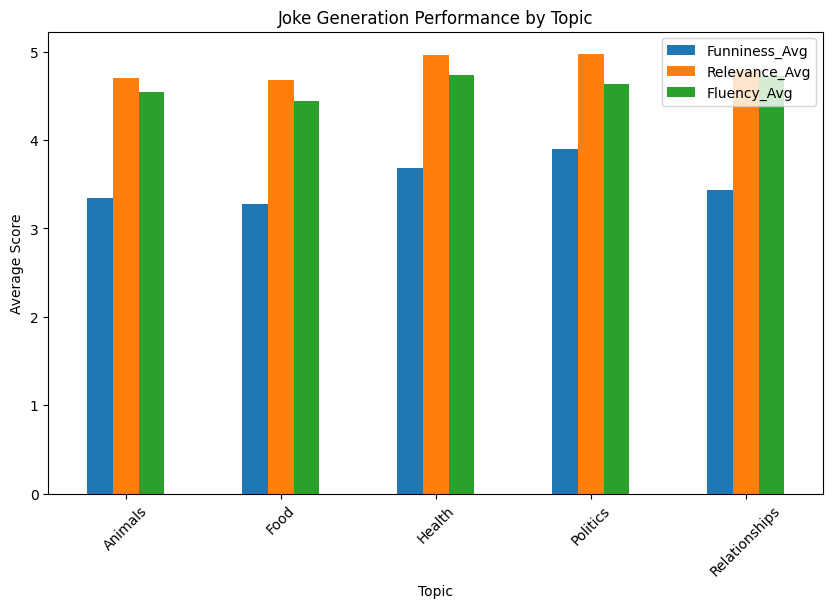

In [ ]:
import matplotlib.pyplot as plt

topic_results.plot(kind="bar", figsize=(10,6))
plt.title("Joke Generation Performance by Topic")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.show()

# **support evaluation by [VitalContribution/JokeDetectBERT](https://huggingface.co/VitalContribution/JokeDetectBERT/tree/main)**

In [ ]:
from transformers import pipeline
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) Load your evaluated jokes file
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLP/joke_evaluation_sheet1.csv")

# 2) Compute human average scores
df["Funniness_Avg"] = df[["Fun_R1","Fun_R2","Fun_R3","Fun_R4","Fun_R5"]].mean(axis=1)
df["Relevance_Avg"] = df[["Rel_R1","Rel_R2","Rel_R3","Rel_R4","Rel_R5"]].mean(axis=1)
df["Fluency_Avg"] = df[["Flu_R1","Flu_R2","Flu_R3","Flu_R4","Flu_R5"]].mean(axis=1)

# 3) Load the humor classifier
classifier = pipeline(
    "text-classification",
    model="VitalContribution/JokeDetectBERT",
    truncation=True
)

# 4) Convert probability to 1–5 score
def convert_prob_to_score(prob, min_score=1.0, max_score=5.0):
    return min_score + prob * (max_score - min_score)

# 5) Store automatic results
auto_labels = []
auto_probs = []
auto_scores = []

# 6) Run model on each generated joke
for joke in df["Generated_Joke"].astype(str):
    result = classifier(joke)[0]

    label = result["label"]
    score = float(result["score"])

    # According to the model card example:
    # LABEL_1 = JOKE
    # LABEL_0 = NO JOKE
    if label == "LABEL_1":
        humor_prob = score
    else:
        humor_prob = 1 - score

    humor_score_1_5 = convert_prob_to_score(humor_prob, 1.0, 5.0)

    auto_labels.append(label)
    auto_probs.append(humor_prob)
    auto_scores.append(humor_score_1_5)

# 7) Add automated evaluation columns
df["Auto_Humor_Label"] = auto_labels
df["Auto_Humor_Prob"] = auto_probs
df["Auto_Humor_Score"] = auto_scores

# 8) Compare automated humor score with human funniness average
mae = mean_absolute_error(df["Funniness_Avg"], df["Auto_Humor_Score"])
rmse = np.sqrt(mean_squared_error(df["Funniness_Avg"], df["Auto_Humor_Score"]))
corr = df["Funniness_Avg"].corr(df["Auto_Humor_Score"])

print("=== Overall Comparison ===")
print("Correlation:", round(corr, 4))
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))

# 9) Topic-level comparison
topic_compare = df.groupby("Topic")[["Funniness_Avg", "Auto_Humor_Score", "Relevance_Avg", "Fluency_Avg"]].mean()

print("\n=== Topic-level Comparison ===")
print(topic_compare)

# 10) Save results if needed
df.to_csv("/content/drive/MyDrive/Colab Notebooks/NLP/joke_evaluation_with_auto_scores.csv", index=False)
topic_compare.to_csv("/content/drive/MyDrive/Colab Notebooks/NLP/topic_compare_human_vs_auto.csv")

# 11) Preview first rows
print("\n=== Sample Output ===")
print(df[["Topic", "Generated_Joke", "Funniness_Avg", "Auto_Humor_Label", "Auto_Humor_Prob", "Auto_Humor_Score"]].head())

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


=== Overall Comparison ===
Correlation: 0.0546
MAE: 1.2135
RMSE: 1.3676

=== Topic-level Comparison ===
               Funniness_Avg  Auto_Humor_Score  Relevance_Avg  Fluency_Avg
Topic                                                                     
Animals                 3.34          4.980727           4.70         4.54
Food                    3.28          4.285683           4.68         4.44
Health                  3.68          4.670818           4.96         4.74
Politics                3.90          4.596825           4.98         4.64
Relationships           3.44          4.373917           4.78         4.72

=== Sample Output ===
           Topic                                     Generated_Joke  \
0  Relationships  Being in a relationship is a lot like doing a ...   
1  Relationships  Our relationship is like a software update; I ...   
2  Relationships  My partner said we need to communicate better,...   
3  Relationships  In relationships, I’ve learned that arguing ab

# **Human vs Automated Humor Scores by Topic**

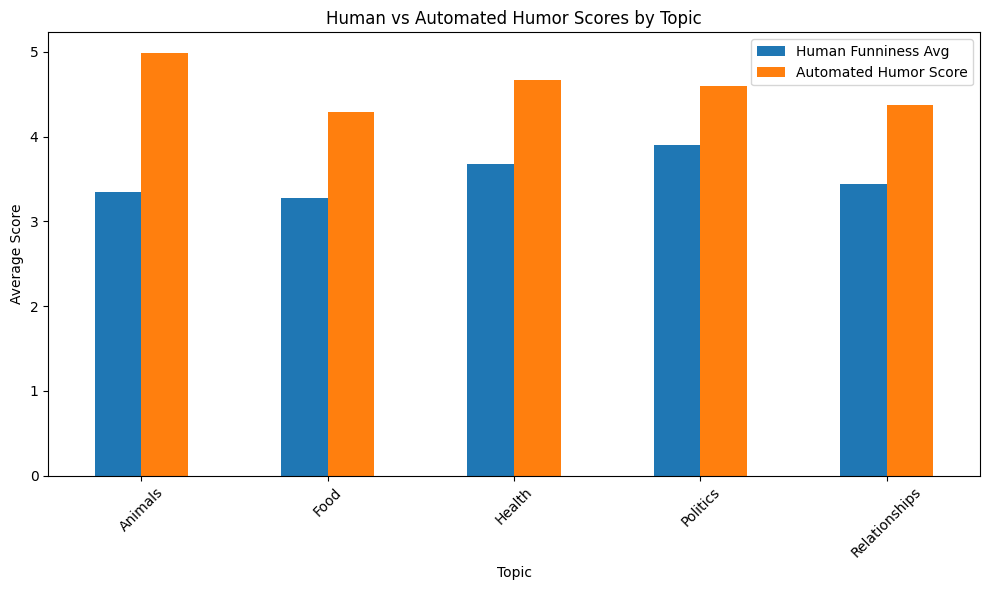

In [ ]:
import matplotlib.pyplot as plt


topic_compare = df.groupby("Topic")[["Funniness_Avg", "Auto_Humor_Score"]].mean()


topic_compare.plot(kind="bar", figsize=(10,6))

plt.title("Human vs Automated Humor Scores by Topic")
plt.xlabel("Topic")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.legend(["Human Funniness Avg", "Automated Humor Score"])
plt.tight_layout()
plt.show()

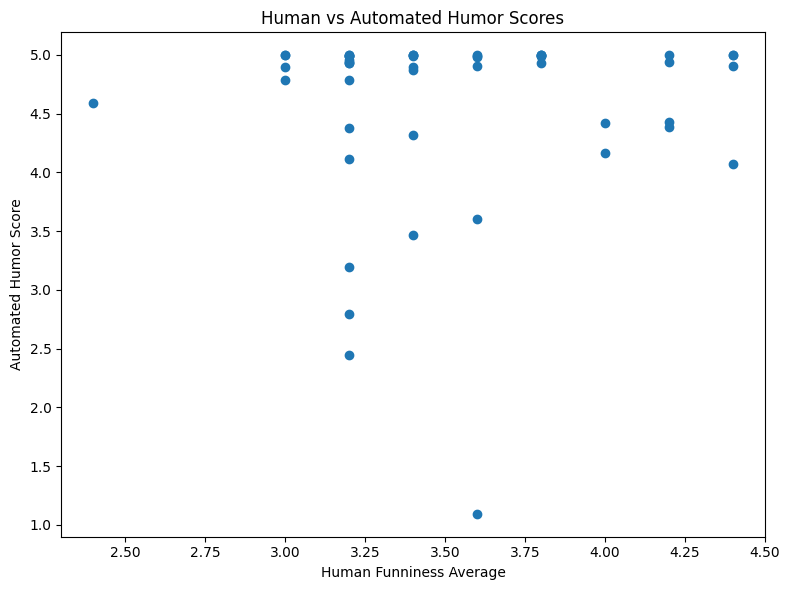

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["Funniness_Avg"], df["Auto_Humor_Score"])

plt.title("Human vs Automated Humor Scores")
plt.xlabel("Human Funniness Average")
plt.ylabel("Automated Humor Score")
plt.tight_layout()
plt.show()

In [ ]:
print(df["Funniness_Avg"].describe())

count    50.000000
mean      3.528000
std       0.449508
min       2.400000
25%       3.200000
50%       3.400000
75%       3.800000
max       4.400000
Name: Funniness_Avg, dtype: float64


# **mohameddhiab/humor-no-humor**

In [ ]:
from transformers import pipeline
import pandas as pd
import numpy as np

# load your evaluated jokes file
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NLP/joke_evaluation_sheet1.csv")

# compute human averages
df["Funniness_Avg"] = df[["Fun_R1","Fun_R2","Fun_R3","Fun_R4","Fun_R5"]].mean(axis=1)
df["Relevance_Avg"] = df[["Rel_R1","Rel_R2","Rel_R3","Rel_R4","Rel_R5"]].mean(axis=1)
df["Fluency_Avg"] = df[["Flu_R1","Flu_R2","Flu_R3","Flu_R4","Flu_R5"]].mean(axis=1)

# load humor classifier
classifier = pipeline(
    "text-classification",
    model="mohameddhiab/humor-no-humor",
    truncation=True
)

def convert_prob_to_score(prob, min_score=1.0, max_score=5.0):
    return min_score + prob * (max_score - min_score)

auto_labels = []
auto_probs = []
auto_scores = []

for joke in df["Generated_Joke"].astype(str):
    result = classifier(joke)[0]

    label = result["label"]
    score = float(result["score"])

    # adjust depending on returned label name
    # if label means humorous, keep score
    # if label means non-humorous, flip score
    if label.lower() in ["funny", "humor", "humorous", "label_1"]:
        humor_prob = score
    else:
        humor_prob = 1 - score

    humor_score_1_5 = convert_prob_to_score(humor_prob, 1.0, 5.0)

    auto_labels.append(label)
    auto_probs.append(humor_prob)
    auto_scores.append(humor_score_1_5)

df["Auto_Humor_Label"] = auto_labels
df["Auto_Humor_Prob"] = auto_probs
df["Auto_Humor_Score"] = auto_scores

print(df[["Generated_Joke", "Funniness_Avg", "Auto_Humor_Prob", "Auto_Humor_Score"]].head())

config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

                                      Generated_Joke  Funniness_Avg  \
0  Being in a relationship is a lot like doing a ...            3.6   
1  Our relationship is like a software update; I ...            3.4   
2  My partner said we need to communicate better,...            3.4   
3  In relationships, I’ve learned that arguing ab...            3.2   
4  Falling in love is like a software update; you...            3.2   

   Auto_Humor_Prob  Auto_Humor_Score  
0         0.991260          4.965038  
1         0.978857          4.915427  
2         0.978668          4.914671  
3         0.902134          4.608535  
4         0.987801          4.951203  


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# overall comparison
mae = mean_absolute_error(df["Funniness_Avg"], df["Auto_Humor_Score"])
rmse = np.sqrt(mean_squared_error(df["Funniness_Avg"], df["Auto_Humor_Score"]))
corr = df["Funniness_Avg"].corr(df["Auto_Humor_Score"])

print("=== Overall Comparison ===")
print("Correlation:", round(corr, 4))
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))


=== Overall Comparison ===
Correlation: -0.0269
MAE: 1.7138
RMSE: 1.874
